In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kritanjalijain/amazon-reviews")

print("Path to dataset files:", path)

In [3]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv(path + "/train.csv")
print(df.head())

   2                     Stuning even for the non-gamer  \
0  2              The best soundtrack ever to anything.   
1  2                                           Amazing!   
2  2                               Excellent Soundtrack   
3  2  Remember, Pull Your Jaw Off The Floor After He...   
4  2                            an absolute masterpiece   

  This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^  
0  I'm reading a lot of reviews saying that this ...                                                                                                                                                                                                  

### Data overview

In [4]:
# The column names are actually a row let's extract it and change the column names and put it into the the actual data
newRow = pd.DataFrame([df.columns.tolist()], columns = df.columns)
df = pd.concat([newRow, df], ignore_index = True)

# Renaming the data columns
df.columns = ['Polarity', 'Title', 'Text']
df

,Polarity,Title,Text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."
...,...,...,...
3599995,1,Don't do it!!,The high chair looks great when it first comes...
3599996,1,"Looks nice, low functionality",I have used this highchair for 2 kids now and ...
3599997,1,"compact, but hard to clean","We have a small house, and really wanted two o..."
3599998,1,what is it saying?,not sure what this book is supposed to be. It ...


In [7]:
print("Shape: ", df.shape)        # rows, columns

Shape:  (3600000, 3)


In [8]:
print(df.info())       # dtypes, null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 3 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   Polarity  object
 1   Title     object
 2   Text      object
dtypes: object(3)
memory usage: 82.4+ MB
None


### Class Distribution

In [ ]:
print(df.describe())   # stats

        Polarity         Title  \
count    3600000       3599793   
unique         3       2628752   
top            1  Disappointed   
freq     1800000          9623   

                                                     Text  
count                                             3600000  
unique                                            3594783  
top     I bought a QPS back in April, I had configurat...  
freq                                                   15  


In [ ]:
# Polarity Distribution
print(df['Polarity'].value_counts(normalize=True))

Polarity
1    5.000000e-01
2    4.999997e-01
2    2.777778e-07
Name: proportion, dtype: float64


In [ ]:
print(df['Polarity'].value_counts())

Polarity
1    1800000
2    1799999
2          1
Name: count, dtype: int64


In [18]:
# -> Found one inconsistent label ('2 ' with whitespace), will clean it.

# Convert to string, strip whitespace, and convert back to int
df['Polarity'] = df['Polarity'].astype(str).str.strip()

# Convert back to int
df['Polarity'] = df['Polarity'].astype(int)

# Check again
print(df['Polarity'].value_counts())


Polarity
2    1800000
1    1800000
Name: count, dtype: int64


### Checking missing and duplicate values

In [19]:
# Checking Review Length
df['Review_Length'] = df['Text'].apply(len)
print(df['Review_Length'].describe())

count    3.600000e+06
mean     4.051396e+02
std      2.342711e+02
min      4.000000e+00
25%      2.070000e+02
50%      3.560000e+02
75%      5.660000e+02
max      1.010000e+03
Name: Review_Length, dtype: float64


In [20]:
# Check for missing values / Duplicates
print(df.isnull().sum(), "\n")
print(df.duplicated().sum())

Polarity           0
Title            207
Text               0
Review_Length      0
dtype: int64 

0


### Visualisation

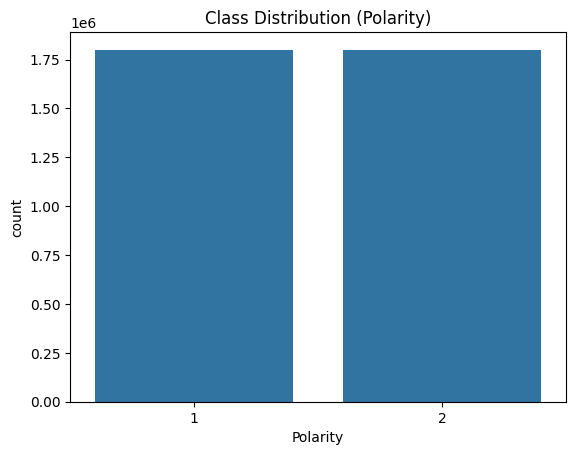

In [21]:
# Polarity Distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Polarity', data=df)
plt.title("Class Distribution (Polarity)")
plt.show()

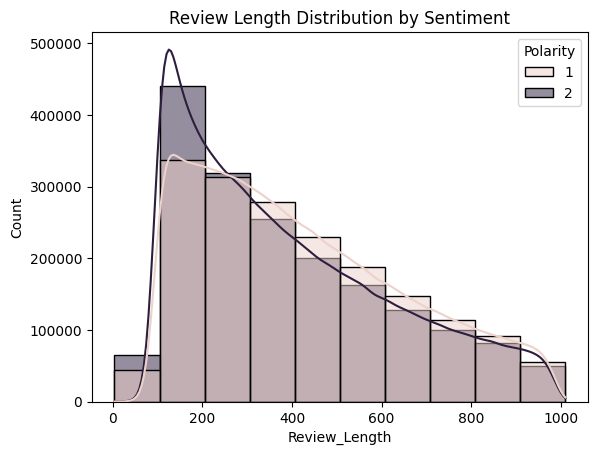

In [23]:
# Distribution of text length per class (are negative reviews longer than positive, etc)
sns.histplot(data=df, x='Review_Length', hue='Polarity', bins=10, kde=True)
plt.title("Review Length Distribution by Sentiment")
plt.show()

In [24]:
df['Review_Length'].skew()

np.float64(0.6379278043489403)

In [25]:
df['Review_Length'].describe(percentiles=[.25, .5, .75, .90, .95, .99])


count    3.600000e+06
mean     4.051396e+02
std      2.342711e+02
min      4.000000e+00
25%      2.070000e+02
50%      3.560000e+02
75%      5.660000e+02
90%      7.680000e+02
95%      8.630000e+02
99%      9.570000e+02
max      1.010000e+03
Name: Review_Length, dtype: float64

### Common words / N-Grams

In [26]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['Text'])

word_counts = Counter(dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1)))
print(word_counts.most_common(20))


[('book', np.int64(1801100)), ('like', np.int64(991462)), ('just', np.int64(907320)), ('good', np.int64(841749)), ('great', np.int64(800082)), ('read', np.int64(641939)), ('time', np.int64(633163)), ('really', np.int64(549453)), ('movie', np.int64(539911)), ('don', np.int64(519470)), ('love', np.int64(414767)), ('buy', np.int64(393965)), ('use', np.int64(391319)), ('cd', np.int64(385073)), ('product', np.int64(383206)), ('better', np.int64(372461)), ('bought', np.int64(365573)), ('work', np.int64(355929)), ('did', np.int64(353289)), ('way', np.int64(336339))]
